In [3]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info:str

In [6]:
def start_play(state:State):
    print("Start play called")
    return {"graph_info": state['graph_info'] + " Starting play"}

def cricket(state:State):
    print("Cricket called")
    return {"graph_info": state['graph_info'] + " Cricket"}

def football(state:State):
    print("Football called")
    return {"graph_info": state['graph_info'] + " Football"}

In [7]:
import random
from typing import Literal

def random_play(state:State) -> Literal['cricket', 'football']:
    graph_info = state['graph_info']

    if random.random() > 0.5:
        return "cricket"
    else:
        return "football"

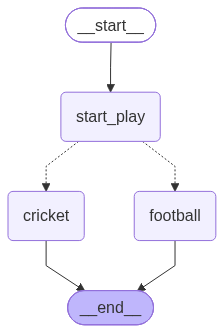

In [15]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

graph_build = graph.compile()

display(Image(graph_build.get_graph().draw_mermaid_png()))

In [39]:
graph_build.invoke({"graph_info": "Hi, the langgraph is invoked"})

Start play called
Cricket called


{'graph_info': 'Hi, the langgraph is invoked Starting play Cricket'}